# MAGE 4 Analysis Summary

 #### Imports

In [1]:
import h5py
import numpy as np
from datetime import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import os
from os import listdir
from scipy import signal
from scipy.signal import welch, csd
from scipy.signal import find_peaks
import lmfit
from scipy.fft import fft, fftfreq
import nexusformat.nexus as nx
from matplotlib.pyplot import cm
import scipy.constants
from lmfit.models import LorentzianModel, ConstantModel
import sys
import os
import pickle
# Specify the absolute path to the 'libraries' directory
library_path = r'C:\Users\00103619\GitHub\MAGE-Data-Analysis\MAGE\MAGE4'  # Adjust this to the actual absolute path

# Add the 'libraries' directory to sys.path
sys.path.append(library_path)

# Now you can import utils.py as a module
import Analysis_functions

In [2]:
folder = r'C:\Users\00103619\MAGE\MAGE4\Analysis/'
meta_file = r'C:\Users\00103619\MAGE\MAGE4\run7\run7-1.hdf5'

In [3]:
with open(folder + '/run7-Teff/event_catalogue-pub.pkl', 'rb') as f:
    event_catalogue_run7 = pickle.load(f)   
with open(folder + '/run7-Teff/co_event_strain-pub.pkl', 'rb') as f:
    co_events_run7 = pickle.load(f)

with open(folder + '/run4-Teff/event_catalogue-pub.pkl', 'rb') as f:
    event_catalogue_run4 = pickle.load(f)
with open(folder + '/run4-Teff/co_event_strain-pub.pkl', 'rb') as f:
    co_events_run4 = pickle.load(f)

with open(folder + '/run3-Teff/event_catalogue-strain-Half.pkl', 'rb') as f:
    event_catalogue_run3 = pickle.load(f)
with open(folder + '/run3-Teff/co_event_strain-Half.pkl', 'rb') as f:
    co_events_run3 = pickle.load(f)

with open(folder + '/run8-Teff/event_catalogue-pub.pkl', 'rb') as f:
    event_catalogue_run8 = pickle.load(f)
with open(folder + '/run8-Teff/co_event_strain-pub.pkl', 'rb') as f:
    co_events_run8 = pickle.load(f)

with open(folder + '/run9-Teff/event_catalogue-pub.pkl', 'rb') as f:
    event_catalogue_run9 = pickle.load(f)
with open(folder + '/run9-Teff/co_event_strain-pub.pkl', 'rb') as f:
    co_events_run9 = pickle.load(f)

with open(folder + '/run10-Teff/event_catalogue-pub.pkl', 'rb') as f:
    event_catalogue_run10 = pickle.load(f)
with open(folder + '/run10-Teff/co_event_strain-pub.pkl', 'rb') as f:
    co_events_run10 = pickle.load(f)

with open(folder + '/run11-Teff/event_catalogue-pub.pkl', 'rb') as f:
    event_catalogue_run11 = pickle.load(f)
with open(folder + '/run11-Teff/co_event_strain-pub.pkl', 'rb') as f:
    co_events_run11 = pickle.load(f)

In [47]:
run10_badfiles = [243, 244, 245, 246 ,247, 248]
remove_list = [event for event in event_catalogue_run10 if event_catalogue_run10[event]['file N'] in run10_badfiles]
co_remove_list = [i for i in range(len(co_events_run10)) if co_events_run10[i][0][1]['file N'] in run10_badfiles]
for k in remove_list:
    event_catalogue_run10.pop(k, None)

co_events_run10 = np.delete(co_events_run10, co_remove_list, axis=0)

run11_badfiles = [69]
remove_list = [event for event in event_catalogue_run11 if event_catalogue_run11[event]['file N'] in run11_badfiles]
co_remove_list = [i for i in range(len(co_events_run11)) if co_events_run11[i][0][1]['file N'] in run11_badfiles]

for k in remove_list:
    event_catalogue_run11.pop(k, None)

co_events_run11 = np.delete(co_events_run11, co_remove_list, axis=0)

In [48]:
co_events_all = np.concatenate((np.array(co_events_run4), np.array(co_events_run7), np.array(co_events_run8), np.array(co_events_run9),
                                np.array(co_events_run10), np.array(co_events_run11)), axis=0)

# PBH Exclusion

Binaries are exclusing by finding the maximum simultaneous SNR in each detector recorded at the same time. Reverting this SNR back to the optimally filtered strain $h_{of}$ and converting to detected charcteristic strain, giving a final distance from which we can reach PBH binaries

### code


In [49]:
feffective_mass = open(r'C:\Users\00103619\MAGE\MAGE4\calibration/Meff.txt')
mode_distributions = np.genfromtxt(feffective_mass, delimiter=',', skip_header=1)
meff = mode_distributions[:,1]
xi = mode_distributions[:,2]

Q0 = [18058011.18, 1254696.59, 3494654.17,16962105.92, 5689899.46, 60565757.57, 33267926.78, 44653062.80, 30585969.48, 26510994.90
    , 37422944.61, 76843447.08, 93176978.34, 65648054.33, 115047095.19, 75204332.18]
Q1 = [48270564.00,630770.50,6453914.00,56212596.00,6115535.00,66870760.00,79754832.00,44126040.00,63588400.00,18052478.00,52137668.00,29066436.00,119769688.00,99094616.00,163072160.00,23392774.00]

Ninputs, Nchannels, Nsamples, Fs, dt, fdemods, t_start = Analysis_functions.get_meta_data_from_first_file(meta_file) 
iq = Analysis_functions.retrieve_IQ_td(meta_file)
freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=2**13)

cali_file_path = r'C:\Users\00103619\MAGE\MAGE4\calibration'
from scipy.constants import k
def read_two_column_data(file_path):
    data = np.loadtxt(file_path)
    column_1 = data[:, 0]  # First column
    column_2 = data[:, 1]  # Second column
    return np.array([column_1, column_2])


Vphi = np.transpose(np.genfromtxt(cali_file_path + '/Vphi-run7.csv',delimiter=',')/1e6)
Rbaw = read_two_column_data(cali_file_path + '/Rs_new.txt')
Lin = 400e-9
Min = np.array([1 / 0.49 / 1e-6, 1 / 0.517 / 1e-6])
meff = Analysis_functions.get_eff_mass(cali_file_path + '/Meff.txt')

In [50]:
def u_to_strain(u, w, w0, xi, Q0):
        return np.abs(u/((-w**2/2*1.093e-3*xi)/(-w**2+w0/(2*Q0)*w*1j+w0**2)))

We need to determine effective bandwidth of each mode from its spectral strain sensitivity Sx, we will do that by taking measured data from a single file

In [51]:
import scipy.integrate


Qs = np.array([Q0,Q1])
delta_f = np.zeros((Ninputs, Nchannels))
for ai in range(2):
    for channel in range(16):
        kappa = np.sqrt(fdemods[ai,channel]*2*np.pi*meff[channel]/(Qs[ai,channel]*Rbaw[ai,channel]))
        Su = np.sqrt(Sx[ai, channel, :])/(2000*Vphi[ai, channel]*Min[ai]*2*np.pi*fdemods[ai,channel]*kappa)
        Sh = u_to_strain(Su, (freqs[ai, channel,:]+fdemods[ai,channel])*2*np.pi, 2*np.pi*(freqs[ai,channel,np.where(Su==np.max(Su))[0][0]]+fdemods[ai,channel]), xi[channel], Qs[ai, channel])

        Sh_trim = Sh[np.where(Sh==np.min(Sh))[0][0]:-1]
        freq_trim = freqs[ai, channel, np.where(Sh==np.min(Sh))[0][0]:-1] + fdemods[ai, channel]

        intval = scipy.integrate.simpson(1/Sh_trim**2, x=freq_trim)
        delta_f[ai, channel] = 2*intval*np.min(Sh**2)
  

In [52]:
u_det_SNR1 = np.zeros((2,Nchannels))
for AI in range(2):
    for ch in range(Nchannels):
          SNR1_3 = [np.abs(event_catalogue_run3[event]['amplitude']) for event in event_catalogue_run3 if (2.9<event_catalogue_run3[event]['SNR'] < 3.1) and event_catalogue_run3[event]['channel']==ch+1
               and event_catalogue_run3[event]['input AI'] == AI]

          SNR1_4 = [np.abs(event_catalogue_run4[event]['amplitude']) for event in event_catalogue_run4 if (2.9<event_catalogue_run4[event]['SNR'] < 3.1) and event_catalogue_run4[event]['channel']==ch+1
               and event_catalogue_run4[event]['input AI'] == AI]
          SNR1_7 = [np.abs(event_catalogue_run7[event]['amplitude']) for event in event_catalogue_run7 if (2.9<event_catalogue_run7[event]['SNR'] < 3.1) and event_catalogue_run7[event]['channel']==ch+1
               and event_catalogue_run7[event]['input AI'] == AI]
          SNR1_10 = [np.abs(event_catalogue_run10[event]['amplitude']) for event in event_catalogue_run10 if (2.9<event_catalogue_run10[event]['SNR'] < 3.1) and event_catalogue_run10[event]['channel']==ch+1
               and event_catalogue_run10[event]['input AI'] == AI]
          SNR1_11 = [np.abs(event_catalogue_run11[event]['amplitude']) for event in event_catalogue_run11 if (2.9<event_catalogue_run11[event]['SNR'] < 3.1) and event_catalogue_run11[event]['channel']==ch+1
               and event_catalogue_run11[event]['input AI'] == AI]
          SNR1_8 = [np.abs(event_catalogue_run8[event]['amplitude']) for event in event_catalogue_run8 if (2.9<event_catalogue_run8[event]['SNR'] < 3.1) and event_catalogue_run8[event]['channel']==ch+1
               and event_catalogue_run8[event]['input AI'] == AI]

          SNR1 = np.concatenate((SNR1_4,SNR1_7,SNR1_8,SNR1_10,SNR1_11))
          u_det_SNR1[AI, ch] = np.mean(SNR1)



In [53]:
Texcl = np.zeros(16)
hcexcl = np.zeros((2,16))
hcexcl_outside = np.zeros((Nchannels, 100))
fvec = np.zeros(16)
Mvec = np.zeros(16)
Dexcl = np.zeros(16)
Dexcl_outside = np.zeros((Nchannels, 100))
fvec_outside = np.zeros((Nchannels, 100))
Mvec_outside = np.zeros((Nchannels, 100))
f_end2 = 1.2439e9
f_end = 1.14e12
for i in range(Nchannels):
    channel=i
    channel_events = [event for event in co_events_run7 if event[0][1]['channel'] == channel+1]
    events_3std = [event for event in channel_events if event[0][1]['SNR'] > 3 and  event[1][1]['SNR'] > 3]
    if len(events_3std)==0:
        events_2std = [event for event in channel_events if event[0][1]['SNR'] > 2 and  event[1][1]['SNR'] > 2]
        R_combined = np.max([event[0][1]['SNR'] + event[1][1]['SNR'] for event in events_2std])
        target_event0 = [event for event in events_2std if event[0][1]['SNR'] + event[1][1]['SNR'] == R_combined]
        print(R_combined)
    else:
        R_combined = np.max([event[0][1]['SNR'] + event[1][1]['SNR'] for event in events_3std])
        target_event0 = [event for event in events_3std if event[0][1]['SNR'] + event[1][1]['SNR'] == R_combined]
        print(R_combined)
    
    deth0 = target_event0[0][0][1]['amplitude']
    deth1 = target_event0[0][1][1]['amplitude']


    norm0 = 3.5/target_event0[0][0][1]['Teff']
    norm1 = 3.5/target_event0[0][1][1]['Teff']

    f_demod = target_event0[0][0][1]['frequency']

    normed_deth0, normed_deth1 = np.sqrt(norm0)*np.abs(deth0),  np.sqrt(norm1)*np.abs(deth1)

    T0,T1 = 0.5*np.abs(normed_deth0)**2*(f_demod*2*np.pi)**2*meff[channel]/(1.380649e-23), 0.5*np.abs(normed_deth1)**2*(f_demod*2*np.pi)**2*meff[channel]/(1.380649e-23)
    Texcl[i] = np.array([T0,T1]).max()
    fvec[i] = f_demod
    fn_outside = np.linspace(f_demod,f_end, 100)
    fvec_outside[i, :] = fn_outside
    Mpbh = 4.3758e33/f_demod
    Mpbh_end = 4.3758e33/f_end
    Mpbh_outside =  4.3758e33/fn_outside

    Msolar = 1.989e30
    tau = 83*(Mpbh/(1e-12*Msolar))**(-5/3)*(fn_outside/1e9)**(-8/3)
    hdet0 = u_to_strain(normed_deth0, 2*np.pi*f_demod, 2*np.pi*f_demod, xi[channel], Q0[channel])
    hdet1 = u_to_strain(normed_deth1, 2*np.pi*f_demod, 2*np.pi*f_demod, xi[channel], Q1[channel])
    hcdet0 = hdet0*(f_demod/delta_f[0, channel])
    hcdet1 = hdet1*(f_demod/delta_f[1,channel])
    #hcdet0 = u_to_strain(normed_deth0, 2*np.pi*f_demod, 2*np.pi*f_demod, xi[channel], Q0[channel])/np.sqrt(tau)
    #hcdet1 = u_to_strain(normed_deth1, 2*np.pi*f_demod, 2*np.pi*f_demod, xi[channel], Q1[channel])/np.sqrt(tau)

    
    MM = (Mpbh**2)**(3/5)/(2**(1/5)*Mpbh**(1/5))
    MM_end = (Mpbh_end**2)**(3/5)/(2**(1/5)*Mpbh_end**(1/5))
    Mvec[i] = MM
    MM_outside = (Mpbh_outside**2)**(3/5)/(2**(1/5)*Mpbh_outside**(1/5))
    Mvec_outside[i, :] = MM_outside

    Ncycles = 5.42532e56/(f_demod**(5/3)*MM**(5/3))
    Ncycles_outside = 5.42532e56/(f_demod**(5/3)*MM_outside**(5/3))
    hc0, hc1 = hcdet0/np.sqrt(2*Ncycles), hcdet1/np.sqrt(2*Ncycles)

    hc0_outside, hc1_outside = hcdet0/np.sqrt(2*Ncycles_outside), hcdet1/np.sqrt(2*Ncycles_outside)
    hcexcl[:,i] = np.array([normed_deth0, normed_deth1])
    hcexcl_outside[i, :] = np.array([hc0_outside,hc1_outside]).max()

    D = 5.83209e-51*f_demod**(2/3)*MM**(5/3)/np.array([hc0,hc1]).max()
    D_outside = 5.83209e-51*fn_outside**(2/3)*MM_outside**(5/3)/np.array([hc0_outside,hc1_outside]).max()
    Dexcl[i] = D
    Dexcl_outside[i,:] = D_outside

7.581711289403451
9.280350922723116
7.598774080442565
8.157026593471926
7.866388113538868
6.998668014585553
6.942610322657317
6.65052866078587
7.946525879484207
8.035947500396702
9.615939934158135
8.483568583620182
7.1746431073172445
9.794870458320752
8.09805673461748
7.668672103992998


In [62]:
hc_inv = 0

N=15
f_vec2 = f_end2
hc_inv_vec2 = 0
Mpbh = 4.3758e33/fdemods[0][15]
Mpbh_vec2 = 4.3758e33/f_vec2
MM = (Mpbh**2)**(3/5)/(2**(1/5)*Mpbh**(1/5))
MM_vec2 = (Mpbh_vec2**2)**(3/5)/(2**(1/5)*Mpbh_vec2**(1/5)) 
for i in range(N+1):
    hdet0 = u_to_strain(u_det_SNR1[0, i], 2*np.pi*fdemods[0][i], 2*np.pi*fdemods[0][i], xi[i], Q0[i])
    hdet1 = u_to_strain(u_det_SNR1[1, i], 2*np.pi*fdemods[0][i], 2*np.pi*fdemods[0][i], xi[i], Q1[i])
    Ncycles = 5.42532e56/(fdemods[0][i]**(5/3)*MM**(5/3))
    Ncycles_vec2 = 5.42532e56/(fdemods[0][i]**(5/3)*MM_vec2**(5/3))
    hc0 = hdet0/np.sqrt(2*Ncycles)*(fdemods[0][N]/delta_f[0, i])
    hc0_vec2 =hdet0/np.sqrt(2*Ncycles_vec2)*(f_end2/delta_f[0, i])

    hc1 = hdet1/np.sqrt(2*Ncycles)*(fdemods[1][N]/delta_f[1, i])
    hc1_vec2 =hdet1/np.sqrt(2*Ncycles_vec2)*(f_end2/delta_f[1, i])
    hc_inv += (1/hc0 + 1/hc1)

    hc_inv_vec2 += 1/hc0_vec2 + 1/hc1_vec2
    
hc_total = 1/hc_inv
hc_vec =  1/hc_inv_vec2

In [63]:
Dexcl_total = 5.83209e-51*f_demod**(2/3)*MM**(5/3)/hc_total/3.0857E+19
Dexcl_2 = 5.83209e-51*f_end2**(2/3)*MM_vec2**(5/3)/hc_vec/3.0857E+19

In [64]:
trun3 = np.abs(datetime(2024, 11, 22, 12, 12, 0 ) - datetime(2024, 12, 5, 8, 40, 0))
trun4 =  np.abs(datetime(2024, 12, 19, 16, 41, 0) - datetime(2025, 1, 13, 8, 26, 0))
trun7 = np.abs( datetime(2025, 1, 29, 10, 19, 0) - datetime(2025, 2, 12, 17, 32, 0))
trun8 = np.abs( datetime(2025, 3, 11, 12, 27,0) - datetime(2025, 3, 12, 10, 49, 0))
trun10 = np.abs( datetime(2025, 3, 17, 13, 19, 0) -datetime(2025, 3, 25, 7, 57, 0))

In [65]:
runttime = trun3 + trun4 +trun7 +trun8 + trun10
total_time = runttime.total_seconds()

In [66]:
def d_to_density(d,Tobs):
    return 1.0/(4/3*np.pi*d**3*Tobs)


### Plots

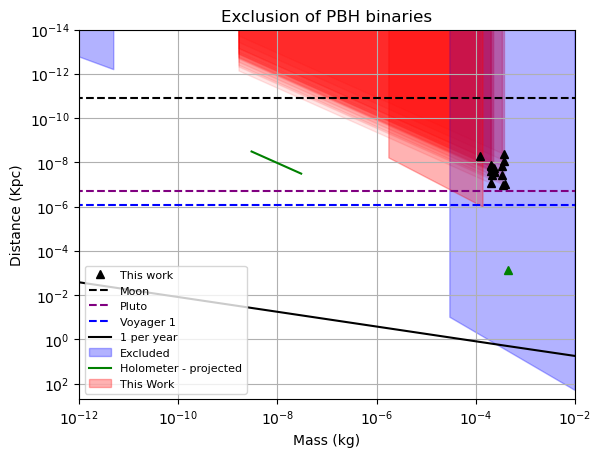

In [67]:
plt.plot(Mvec/Msolar, Dexcl/3.0857E+19, linestyle = ' ', marker='^', color = 'black', label = 'This work')
for i in range(Nchannels):
    plt.fill_between(Mvec_outside[i,:]/Msolar, Dexcl_outside[i,:]/3.0857E+19, color = 'red', alpha = 0.1)


plt.plot([1e18/Msolar, 1e-2], np.array([0.00257,0.00257])*4.848e-9, '--', color='black', label = 'Moon')
plt.plot([1e18/Msolar, 1e-2], np.array([39.5,39.5])*4.848e-9, '--', color='purple', label = 'Pluto')
plt.plot([1e18/Msolar, 1e-2], np.array([167.34,167.34])*4.84e-9, '--', color='Blue', label = 'Voyager 1')
plt.plot(np.array([1e-13, 4.4e-4,1e-2]), np.array([0.00122, 2,5.6]), color = 'black', label = '1 per year')
plt.fill_between(np.array([3e-5, 1e-2]), np.array([1e-1, 200]), color = 'blue', alpha = 0.3)
plt.fill_between(np.array([1e18/Msolar, 1e19/Msolar]), np.array([3e6, 2e7])/3.0857E+19, color = 'blue', alpha = 0.3, label='Excluded')
plt.plot(np.array([6e21/Msolar, 6e22/Msolar]), np.array([1e11, 1e12])/3.0857E+19, color = 'green', label = 'Holometer - projected')
plt.plot(4.4e-4,6.98e-4, marker='^', color = 'green')
#plt.plot(Mpbh/Msolar, Dexcl_total, marker= '^', color = 'red')
plt.fill_between(np.array([Mpbh_vec2/Msolar,Mpbh/Msolar]), np.array([Dexcl_2, Dexcl_total]), color = 'red', alpha = 0.3, label='This Work')
plt.xscale('log')
plt.yscale('log')
plt.grid(which='both')
plt.ylabel('Distance (Kpc)')
plt.xlabel('Mass (kg)')
plt.title('Exclusion of PBH binaries')
plt.legend(loc=3, fontsize=8)
plt.ylim(5e2, 1e-14)
plt.xlim(1e-12,1e-2)
pp = 'PBH-exclusion.pdf'
plt.savefig(pp, format='pdf', dpi=600)

In [68]:
Ligo_data = np.genfromtxt("plot-data-LIGO.csv", skip_header=1, delimiter=',')

In [69]:
Ligo_data

array([[1.140093e-07, 3.670957e+07],
       [1.313901e-07, 2.313844e+07],
       [1.518708e-07, 1.470815e+07],
       ...,
       [2.120124e-05, 4.597619e+03],
       [2.435516e-05, 1.106436e+04],
       [2.811317e-05, 1.277025e+05]])

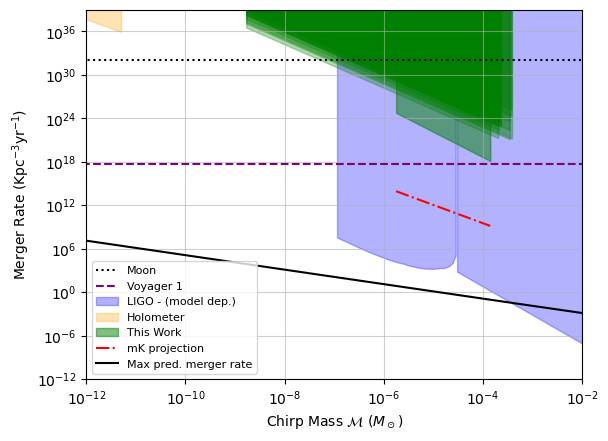

In [76]:
years = 62/365
plt.grid(which='both', alpha=0.6)
#plt.plot(Mvec/Msolar, d_to_density(Dexcl/3.0857E+19,years), linestyle = ' ', marker='^', color = 'black', label = 'This work')
plt.plot([1e18/Msolar, 1e-2], d_to_density(np.array([0.00257,0.00257])*4.848e-9,1), ':', color='black', label = 'Moon')
plt.plot([1e18/Msolar, 1e-2], d_to_density(np.array([167.34,167.34])*4.84e-9,1), '--', color='purple', label = 'Voyager 1')

plt.fill_between(np.array([3e-5, 1e-2]), d_to_density(np.array([1e-1, 200]), 127/365), y2=1e44, color = 'blue', alpha = 0.3)
plt.fill_between(Ligo_data[:,0], Ligo_data[:,1], y2=1e44, color = 'blue', alpha = 0.3, label='LIGO - (model dep.)')
plt.fill_between(np.array([1e18/Msolar, 1e19/Msolar]), d_to_density(np.array([3e6, 2e7])/3.0857E+19,1), y2=1e44, color = 'orange', alpha = 0.3, label='Holometer')
# plt.plot(np.array([6e21/Msolar, 6e22/Msolar]), np.array([1e11, 1e12])/3.0857E+19, color = 'green', label = 'Holometer - projected')
#plt.plot(Mpbh/Msolar, d_to_density(Dexcl_total,60/365), marker= '^', color = 'red')
for i in range(Nchannels):
    plt.fill_between(Mvec_outside[i,:]/Msolar, d_to_density(Dexcl_outside[i,:]/3.0857E+19,years), y2=1e44, color = 'green', alpha = 0.3)
plt.fill_between(np.array([Mpbh_vec2/Msolar,Mpbh/Msolar]), d_to_density(np.array([Dexcl_2, Dexcl_total]), 60/365), y2=1e44, color = 'green', alpha = 0.5, label='This Work')
plt.plot(np.array([Mpbh_vec2/Msolar,Mpbh/Msolar]),d_to_density(np.array([1.4e-5,5.5e-4]),1), color = 'red', label='mK projection', linestyle='-.')
plt.plot(np.array([1e-13, 4.4e-4,1e-2]), d_to_density(np.array([0.00122, 2,5.6]),1), color = 'black', label = 'Max pred. merger rate')

plt.xscale('log')
plt.yscale('log')

plt.ylabel(r'Merger Rate ($\mathrm{Kpc}^{-3}\mathrm{yr}^{-1}$)')
plt.xlabel(r'Chirp Mass $\mathcal{M}~(M_\odot)$')
# plt.title('Exclusion of PBH binaries')
plt.legend(loc=3, fontsize=8)
plt.ylim(1e-12, 1e39)
plt.xlim(1e-12,1e-2)
pp = 'PBH-exclusion.pdf'
plt.savefig(pp, format='pdf', dpi=600)

In [32]:
Dexcl_total

1.0360738306276972e-06

In [33]:
d_to_density(Dexcl_total,61/365)

1.284405945150282e+18

# Histograms

## Post trigger threshold histogram (entire run)

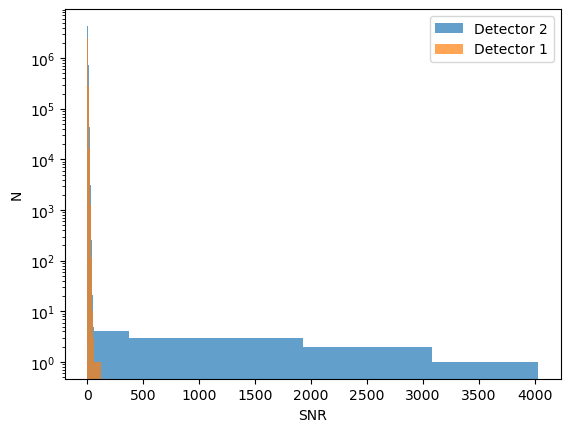

In [38]:
xmin = np.array([(np.array(SNRs0)**2)[:,0].min(),(np.array(SNRs1)**2)[:,0].min()]).min()
xmax = np.array([(np.array(SNRs0)**2)[:,0].max(),(np.array(SNRs1)**2)[:,0].max()]).max()


plt.hist((np.array(SNRs0)**2)[:,0], alpha = 0.7, label = 'Detector 2', bins = 500, range = (xmin, xmax), cumulative=-1)
plt.hist((np.array(SNRs1)**2)[:,0], alpha = 0.7, label = 'Detector 1', bins = 500, range = (xmin, xmax), cumulative=-1)
plt.yscale('log')
plt.xlabel('SNR')
plt.ylabel('N')
#plt.xlim(0,50)
plt.legend(loc=0)
plt.show()

During this run gain in detector 2 was larger, giving rise to more events above threshold.

## Post filter histograms (single file)

#### code

In [633]:
ai = 0
ch = 14
file_i = 10
file_i_2 = 593
index=3679

file_name= r'C:\Users\00103619\MAGE\MAGE4\run9\\' + 'run9-' + str(file_i) + '.hdf5'

In [634]:
Ninputs, Nchannels, Nsamples, Fs, dt, fdemods, t_start = Analysis_functions.get_meta_data_from_first_file(file_name) 
NFFT=2**13
cali_file_path = r'C:\Users\00103619\MAGE\MAGE4\calibration'
from scipy.constants import k
def read_two_column_data(file_path):
    data = np.loadtxt(file_path)
    column_1 = data[:, 0]  # First column
    column_2 = data[:, 1]  # Second column
    return np.array([column_1, column_2])

#Vphi = np.transpose(np.genfromtxt(cali_file_path + '/Vphi-run7.csv',delimiter=',')/1e6)
Vphi = np.array([890, 300])/1e6

Rbaw = read_two_column_data(cali_file_path + '/Rs_new.txt')
Lin = 400e-9
Min = np.array([1 / 0.49 / 1e-6, 1 / 0.517 / 1e-6])
meff = Analysis_functions.get_eff_mass(cali_file_path + '/Meff.txt')
Qs = np.zeros((Ninputs, Nchannels))
f_res = np.zeros_like(Qs)

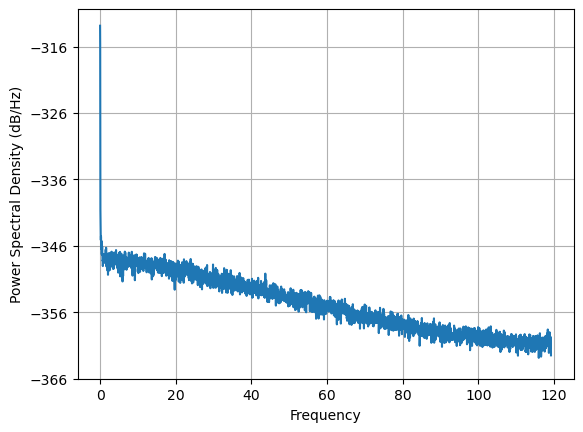

In [636]:
span = 700
offset = 0
time = dt *  np.linspace(index-offset- span, index-offset + span, 2*span)
file_name = r'C:\Users\00103619\MAGE\MAGE4\run9\\' + 'run9-' + str(file_i) + '.hdf5'
iq = Analysis_functions.retrieve_IQ_td(file_name)
i_data = iq[ai, ch, 0, :]
q_data = iq[ai, ch, 1, :]
r_data = np.sqrt(i_data **2 + q_data**2)
freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False)
kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai]*(1+(f_res[ai,ch]/20e6)**2), Min[ai], kappa)
T = 0.5*(fdemods[ai, ch]*2*np.pi)**2*meff[ch]*strain**2/k
tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
Nfilter=int(Fs*20*1) # assume 1s tau
t_sig =1/Fs*np.linspace(0, Nfilter, Nfilter)
template = np.exp(-t_sig/(2*tau)) # template construction
SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
T_filtered = 0.5*(fdemods[ai, ch]*2*np.pi)**2*meff[ch]*np.abs(filtered_strain)**2/k

In [637]:
strain

array([6.652618e-17, 5.389598e-17, 8.573139e-17, ..., 1.879129e-17,
       1.468156e-17, 5.338173e-17])

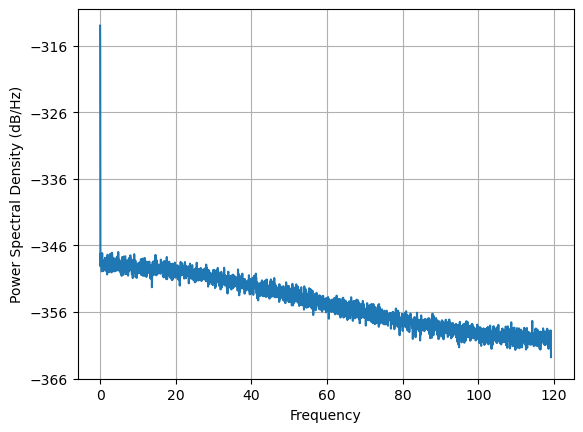

In [642]:
span = 700
offset = 0
time = dt *  np.linspace(index-offset- span, index-offset + span, 2*span)
file_name = r'C:\Users\00103619\MAGE\MAGE4\run4\\' + 'run4--' + str(file_i_2) + '.hdf5'
iq = Analysis_functions.retrieve_IQ_td(file_name)
i_data = iq[ai, ch, 0, :]
q_data = iq[ai, ch, 1, :]
r_data = np.sqrt(i_data **2 + q_data**2)
freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False)
kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai], Min[ai], kappa)
T2 = 0.5*(fdemods[ai, ch]*2*np.pi)**2*meff[ch]*strain**2/k
tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
template = np.exp(-t_sig/(2*tau)) # template construction
SNR2, filtered_strain2 = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
T_filtered2 = 0.5*(fdemods[ai, ch]*2*np.pi)**2*meff[ch]*np.abs(filtered_strain2)**2/k

In [643]:
Nbins = 100
ii=0
jj=30


Tn_height, Tn_edge = np.histogram(T, bins = Nbins)
Tn_height_f, Tn_edge_f = np.histogram(T_filtered, bins = Nbins)
Tn_height_f2, Tn_edge_f2 = np.histogram(T_filtered2, bins = Nbins)

Tfit_m, Tfit_b = np.polyfit(Tn_edge[ii:jj],np.log(Tn_height[ii:jj]),1)
Tfit_m_f, Tfit_b_f = np.polyfit(Tn_edge_f[ii:jj],np.log(Tn_height_f[ii:jj]),1)
Tfit_m_f2, Tfit_b_f2 = np.polyfit(Tn_edge_f2[ii:jj],np.log(Tn_height_f2[ii:jj]),1)

tn_T = np.linspace(0.0,max(Tn_edge)*0.99,Nbins)

#### plots

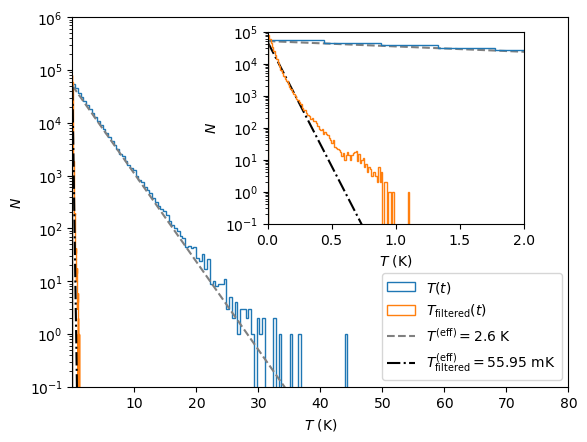

In [644]:
fig, ax1 = plt.subplots()
# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.43, 0.45, 0.4, 0.4]

ax2 = fig.add_axes([left, bottom, width, height])
ax1.hist(T, bins=Nbins, label = r'$T(t)$', density=False, histtype='step')
ax1.hist(np.abs(T_filtered), bins=Nbins, label = r'$T_\mathrm{filtered}(t)$', density=False, histtype='step')
ax1.plot(tn_T,np.exp(Tfit_m*tn_T+Tfit_b), '--', color='gray', label = r'$T^{(\mathrm{eff})}=$%1.1f' % (-1/Tfit_m) + ' K')
ax1.plot(tn_T,np.exp(Tfit_m_f*tn_T+Tfit_b_f), '-.', color = 'black', label = r'$T^{(\mathrm{eff})}_\mathrm{filtered}=$%1.2f' % (-1/Tfit_m_f*1e3) + ' mK')

ax1.set_ylim(0.1,1e6)
ax1.set_yscale('log')
ax1.set_xlim(0.01,80)
ax1.legend(loc=4)
ax1.set_ylabel(r'$N$')
ax1.set_xlabel(r'$T$ (K)')

ax2.plot(tn_T,np.exp(Tfit_m*tn_T+Tfit_b), '--', color='gray')
ax2.plot(tn_T,np.exp(Tfit_m_f*tn_T+Tfit_b_f), '-.', color='black')
ax2.hist(T, bins=Nbins, label = ' u rms', density=False,histtype='step')
ax2.hist(np.abs(T_filtered), bins=Nbins, label = ' u filtered rms', density=False, histtype='step')


ax2.set_xlim(0,2)
ax2.set_ylim(0.1,1e5)
ax2.set_yscale('log')
ax2.set_ylabel(r'$N$')
ax2.set_xlabel(r'$T$ (K)')
pp = 'total-MAGE4-filterHist.pdf'
pp = plt.savefig(pp, format='pdf', dpi=600)

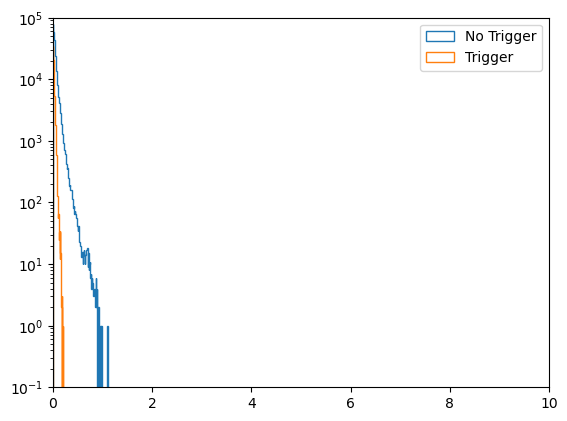

In [645]:
plt.hist(np.abs(T_filtered), bins=Nbins, label = 'No Trigger', density=False, histtype='step')
plt.hist(np.abs(T_filtered2), bins=Nbins, label = 'Trigger', density=False, histtype='step')
#plt.plot(tn_T,np.exp(Tfit_m_f*tn_T+Tfit_b_f), label = r'$T_{eff}=$%1.3f' % (-1/Tfit_m_f) + ' K')
#plt.plot(tn_T,np.exp(Tfit_m_f2*tn_T+Tfit_b_f2), label = r'$T_{eff}=$%1.3f' % (-1/Tfit_m_f2) + ' K')
plt.ylim(0.1,1e5)
plt.xlim(0,10)
plt.yscale('log')
plt.legend()

## Cumulative MAGE4 histogram

### pickles

In [972]:
folder = r'C:\Users\00103619\MAGE\MAGE4\Analysis'

In [38]:

SNRsA1_7 = np.array([(event_catalogue_run7[event]['SNR']) for event in event_catalogue_run7 if event_catalogue_run7[event]['input AI'] == 1])
SNRsA0_7 =  np.array([(event_catalogue_run7[event]['SNR']) for event in event_catalogue_run7 if event_catalogue_run7[event]['input AI'] == 0])

SNRsA1_3 = np.array([(event_catalogue_run3[event]['SNR']) for event in event_catalogue_run3 if event_catalogue_run3[event]['input AI'] == 1])
SNRsA0_3 =  np.array([(event_catalogue_run3[event]['SNR']) for event in event_catalogue_run3 if event_catalogue_run3[event]['input AI'] == 0])

SNRsA1_4 = np.array([(event_catalogue_run4[event]['SNR']) for event in event_catalogue_run4 if event_catalogue_run4[event]['input AI'] == 1])
SNRsA0_4 =  np.array([(event_catalogue_run4[event]['SNR']) for event in event_catalogue_run4 if event_catalogue_run4[event]['input AI'] == 0])

SNRsA1_8 = np.array([(event_catalogue_run8[event]['SNR']) for event in event_catalogue_run8 if event_catalogue_run8[event]['input AI'] == 1])
SNRsA0_8 =  np.array([(event_catalogue_run8[event]['SNR']) for event in event_catalogue_run8 if event_catalogue_run8[event]['input AI'] == 0])

#SNRsA1_9 = np.array([(event_catalogue_run9[event]['SNR']) for event in event_catalogue_run9 if event_catalogue_run9[event]['input AI'] == 1])
#SNRsA0_9 =  np.array([(event_catalogue_run9[event]['SNR']) for event in event_catalogue_run9 if event_catalogue_run9[event]['input AI'] == 0])

SNRsA1_10 = np.array([(event_catalogue_run10[event]['SNR']) for event in event_catalogue_run10 if event_catalogue_run10[event]['input AI'] == 1 ])
SNRsA0_10 =  np.array([(event_catalogue_run10[event]['SNR']) for event in event_catalogue_run10 if event_catalogue_run10[event]['input AI'] == 0 ])

SNRsA1 = np.concatenate([SNRsA1_7, SNRsA1_4, SNRsA1_8, SNRsA1_10])
SNRsA0 = np.concatenate([SNRsA0_7, SNRsA0_4, SNRsA0_8, SNRsA0_10])


In [25]:
total_time/60/60/24

60.518055555555556

### Histograms

In [42]:
from scipy.stats import chi2
from scipy.stats import ncx2
from scipy.stats import norm

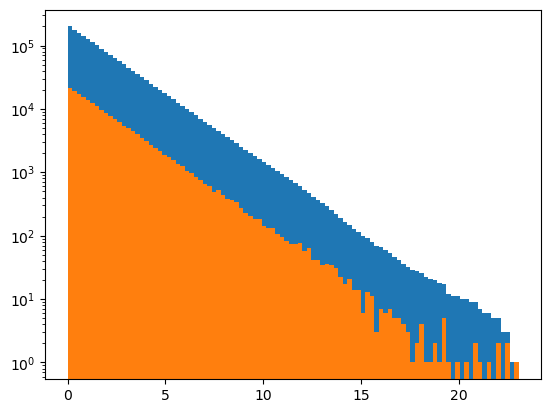

In [43]:
r = chi2.rvs(2, size=200000)
plt.hist(r, bins = 100, cumulative=-1)
plt.hist(r, bins = 100)
plt.yscale('log')

In [44]:
total_time/60/60/24

60.518055555555556

In [45]:
chi2.fit([x for x in SNRsA0**2 if x<20], f0=2)

(2, 1.0000133758688938, 2.2660741420241886)

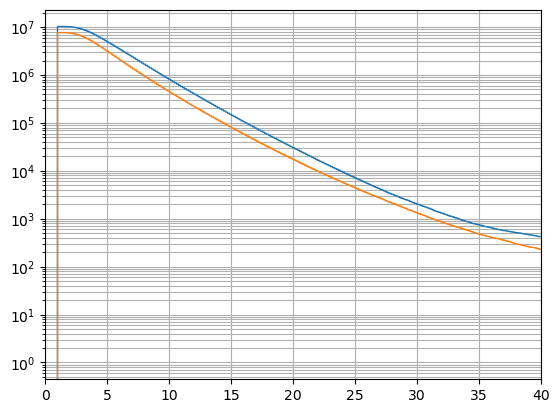

In [46]:
bin_space =np.logspace(np.log10(0.01),np.log10(1e4), 500)

heights, bins, bars = plt.hist(SNRsA0**2, bins=50000, histtype='step', cumulative=-1, density=False)
heights2, bins2, bars2 = plt.hist(SNRsA1**2,bins=50000, histtype='step', cumulative=-1, density=False)
plt.yscale('log')
#plt.xscale('log')
plt.xlim(0,40)
plt.grid(which='both')
plt.show()

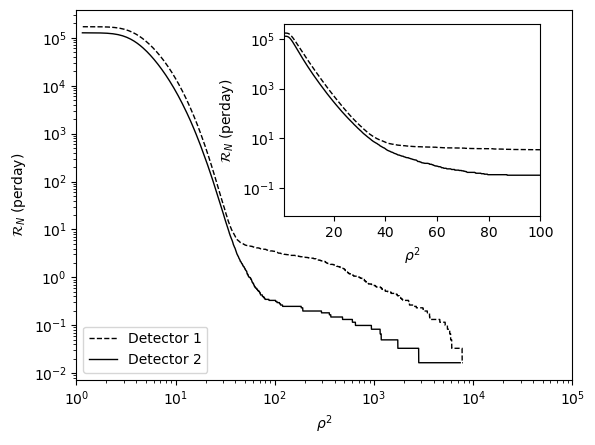

In [47]:
fig, ax1 = plt.subplots()
# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.45, 0.45, 0.4, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
ax1.plot(bins[1:], heights/total_time*60*60*24, '--', color='black', linewidth = 1, label = 'Detector 1')
ax1.plot(bins2[1:], heights2/total_time*60*60*24, '-', color = 'black', linewidth=1, label = 'Detector 2')
ax1.set_xlim(1,1e5)
ax1.set_xlabel(r'$\rho^2$')
ax1.set_ylabel(r'$\mathcal{R}_N~\mathrm{(per day)}$')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.legend(loc=3)

ax2.plot(bins[1:], heights/total_time*60*60*24, '--', color='black', linewidth = 1, label = 'Detector 1')
ax2.plot(bins2[1:], heights2/total_time*60*60*24, '-', color = 'black', linewidth=1, label = 'Detector 2')
ax2.set_xlim(1,100)
ax2.set_xlabel(r'$\rho^2$')
ax2.set_ylabel(r'$\mathcal{R}_N~\mathrm{(per day)}$')
ax2.set_yscale('log')

# pp = 'Total-Hist.pdf'
# plt.savefig(pp, format = 'pdf', dpi=600)

In [48]:
x = bins[30:150]
y = np.log10(heights[30:150])

a, b, = np.polyfit(x, y, 1)

thresh = np.sqrt(-b/a)

### Coincident event histograms

In [49]:
from scipy.stats import chi2
from scipy.stats import ncx2
from scipy.stats import norm

In [98]:
SNRsA1_7 = np.array([(co_events_run7[event][1][1]['SNR']) for event in range(len(co_events_run7))])
SNRsA0_7 = np.array([(co_events_run7[event][0][1]['SNR']) for event in range(len(co_events_run7))])
SNRsA1_3 = np.array([(co_events_run3[event][1][1]['SNR']) for event in range(len(co_events_run3))])
SNRsA0_3 = np.array([(co_events_run3[event][0][1]['SNR']) for event in range(len(co_events_run3))])
SNRsA1_4 = np.array([(co_events_run4[event][1][1]['SNR']) for event in range(len(co_events_run4))])
SNRsA0_4 = np.array([(co_events_run4[event][0][1]['SNR']) for event in range(len(co_events_run4))])

SNRsA1_8 = np.array([(co_events_run8[event][1][1]['SNR']) for event in range(len(co_events_run8))])
SNRsA0_8 = np.array([(co_events_run8[event][0][1]['SNR']) for event in range(len(co_events_run8))])
SNRsA1_10 = np.array([(co_events_run10[event][1][1]['SNR']) for event in range(len(co_events_run10))])
SNRsA0_10 = np.array([(co_events_run10[event][0][1]['SNR']) for event in range(len(co_events_run10))])

SNRsA1_11 = np.array([(co_events_run11[event][1][1]['SNR']) for event in range(len(co_events_run11))])
SNRsA0_11 = np.array([(co_events_run11[event][0][1]['SNR']) for event in range(len(co_events_run11))])

SNRsA1 = np.concatenate([SNRsA1_7, SNRsA1_4, SNRsA1_3, SNRsA1_8, SNRsA1_10, SNRsA1_11])
SNRsA0 = np.concatenate([SNRsA0_7, SNRsA0_4, SNRsA0_3, SNRsA0_8 ,SNRsA0_10, SNRsA0_11])

In [102]:
(len(SNRsA0))/1e5

0.49731

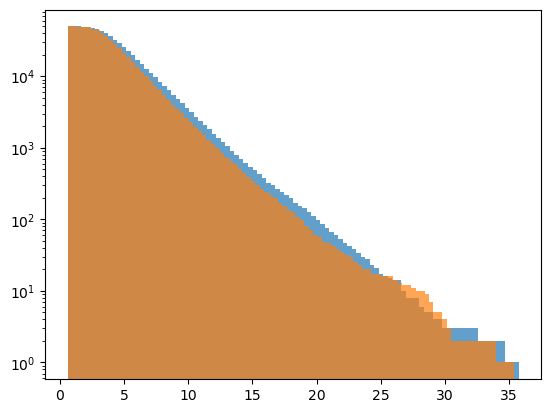

In [70]:
heights_veto0, bins_veto_0, bars = plt.hist(SNRsA0**2, bins=100, alpha=0.7, cumulative=-1)
heights_veto1, bins_veto_1, bars = plt.hist(SNRsA1**2, bins=100, alpha=0.7, cumulative=-1)
#plt.xlim(5,1)
plt.yscale('log')
plt.show()

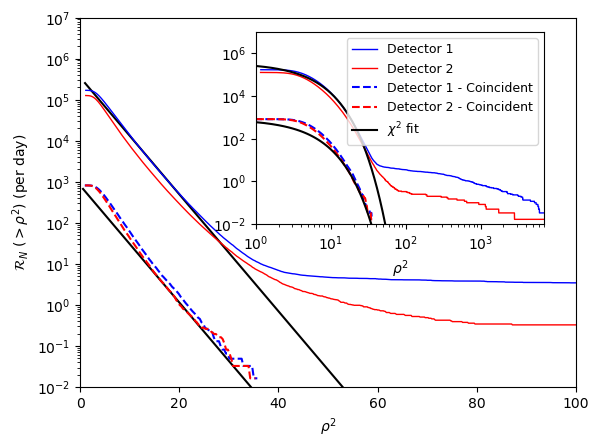

In [71]:
fig, ax2 = plt.subplots()
# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.4, 0.45, 0.45, 0.4]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.plot(bins[1:], heights/61, '-', color='Blue', linewidth = 1, label = 'Detector 1')
ax1.plot(bins2[1:], heights2/61, '-', color = 'Red', linewidth=1, label = 'Detector 2')
ax1.plot(bins_veto_0[1:], heights_veto0/61, '--', color='Blue', linewidth = 1.5, label = 'Detector 1 - Coincident')
ax1.plot(bins_veto_1[1:], heights_veto1/61, '--', color='Red', linewidth = 1.5, label = 'Detector 2 - Coincident')
ax1.plot(bins, 10**(a*bins+b)/61, color='black', linestyle='-', label = r'$\chi^2$ fit')
ax1.plot(bins_veto_0, 10**(a*bins_veto_0+b2)/61, color='black', linestyle='-')
ax1.set_xlim(1,7e3)
ax1.set_ylim(1e-2,1e7)
ax1.set_xlabel(r'$\rho^2$')
ax2.set_ylabel(r'$\mathcal{R}_N~(>\rho^2)~(\mathrm{per~day})$')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.legend(loc=0, fontsize=9)

ax2.plot(bins, 10**(a*bins+b)/61, color='black', linestyle='-')
ax2.plot(bins_veto_0, 10**(a*bins_veto_0+b2)/61, color='black', linestyle='-')
ax2.plot(bins[1:], heights/61, '-', color='Blue', linewidth = 1, label = 'Detector 1')
ax2.plot(bins2[1:], heights2/61, '-', color = 'Red', linewidth=1, label = 'Detector 2')
ax2.plot(bins_veto_0[1:], heights_veto0/61, '--', color='blue', linewidth = 1.5, label = 'Detector 1 - Coincident')
ax2.plot(bins_veto_1[1:], heights_veto1/61, '--', color='red', linewidth = 1.5, label = 'Detector 2 - Coincident')

ax2.set_xlim(0,100)
ax2.set_ylim(1e-2, 1e7)
ax2.set_xlabel(r'$\rho^2$')
ax2.set_ylabel(r'$\mathcal{R}_N~(>\rho^2)~(\mathrm{per~day})$')
ax2.set_yscale('log')
pp = 'Total-Hist2.pdf'
plt.savefig(pp, format = 'pdf', dpi=600)


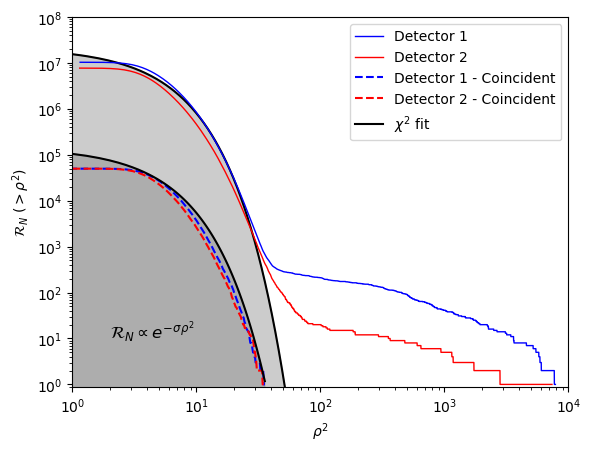

In [90]:
fig, ax2 = plt.subplots()
# These are in unitless percentages of the figure size. (0,0 is bottom left)
#left, bottom, width, height = [0.4, 0.45, 0.45, 0.4]
# ax1 = fig.add_axes([left, bottom, width, height])
# ax1.plot(bins[1:], heights, '-', color='Blue', linewidth = 1, label = 'Detector 1')
# ax1.plot(bins2[1:], heights2, '-', color = 'Red', linewidth=1, label = 'Detector 2')
# ax1.plot(bins_veto_0[1:], heights_veto0, '--', color='Blue', linewidth = 1.5, label = 'Detector 1 - Coincident')
# ax1.plot(bins_veto_1[1:], heights_veto1, '--', color='Red', linewidth = 1.5, label = 'Detector 2 - Coincident')
# ax1.plot(bins, 10**(a*bins+b), color='black', linestyle='-', label = r'$\chi^2$ fit')
# ax1.plot(bins_veto_0, 10**(a*bins_veto_0+b2), color='black', linestyle='-')
# ax1.set_xlim(1,7e3)
# ax1.set_ylim(0.9, 1e8)
# ax1.set_xlabel(r'$\rho^2$')
# ax2.set_ylabel(r'$\mathcal{R}_N~(>\rho^2)$')
# ax1.set_yscale('log')
# ax1.set_xscale('log')
# ax1.legend(loc=0, fontsize=9)

ax2.plot(bins, 10**(a*bins+b), color='black', linestyle='-')

ax2.plot(bins[1:], heights, '-', color='Blue', linewidth = 1, label = 'Detector 1')
ax2.plot(bins2[1:], heights2, '-', color = 'Red', linewidth=1, label = 'Detector 2')
ax2.plot(bins_veto_0[1:], heights_veto0, '--', color='blue', linewidth = 1.5, label = 'Detector 1 - Coincident')
ax2.plot(bins_veto_1[1:], heights_veto1, '--', color='red', linewidth = 1.5, label = 'Detector 2 - Coincident')
ax2.plot(bins_veto_0, 10**(a*bins_veto_0+b2), color='black', linestyle='-', label = r'$\chi^2$ fit')
ax2.fill_between(bins_veto_0, 10**(a*bins_veto_0+b2), color = 'gray', alpha = 0.4)
ax2.fill_between(bins, 10**(a*bins+b), color = 'gray', alpha = 0.4)
ax2.text(2, 10, r"$\mathcal{R}_N\propto e^{-\sigma \rho^2}$", fontsize=12)

ax2.set_xlim(1, 1e4)
ax2.set_ylim(0.9, 1e8)
ax2.set_xlabel(r'$\rho^2$')
ax2.set_ylabel(r'$\mathcal{R}_N~(>\rho^2)$')
ax2.set_yscale('log')
ax2.set_xscale('log')
pp = 'Total-Hist2.pdf'
ax2.legend()
plt.savefig(pp, format = 'pdf', dpi=600)


In [97]:
heights2[0]/1e5

76.85789

In [93]:
a2/b2

-0.03181962693462536

In [62]:
SNRsA1_10 = np.array([(co_events_run10[event][1][1]['SNR']) for event in range(len(co_events_run10))])
SNRsA0_10 = np.array([(co_events_run10[event][0][1]['SNR']) for event in range(len(co_events_run10))])

In [73]:
x = bins_veto_0[5:50]
y = np.log10((heights_veto0)[5:50])

a2, b2, = np.polyfit(x, y, 1)

In [46]:
SNR_noise = np.random.normal(np.mean(SNR), np.std(SNR), size=len(SNR))

As we sample phase and quadreature data, we look at the distribution of the magnitude samples which should follow a chi-squared distribution as the quadratic sum of two gaussian processes

In [295]:
noise = chi2.rvs(2, loc=1, scale=1.0, size=50000000)
test = norm.rvs(loc=0, scale=3.0, size=50000000)


In [307]:
sampled_noise = find_peaks(noise, height = 5.0, distance = int(0.5*Fs), width = [500, 1e6], rel_height=1.0)
sampled_peaks = sampled_noise[1]['peak_heights']
len(sampled_peaks)

64408

In [308]:
norm.fit(sampled_peaks)

(15.30872122451755, 2.6344121541250463)

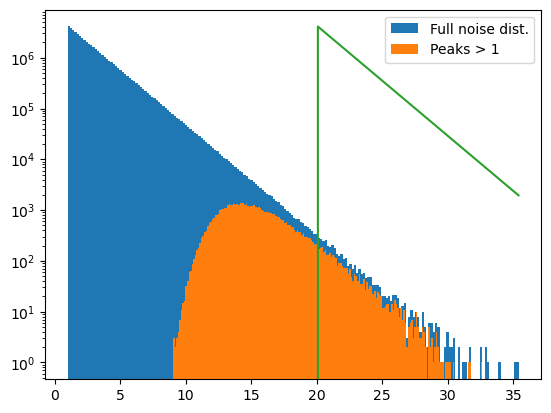

In [337]:
heights, bins, bars = plt.hist(noise, bins=200, density=False, label='Full noise dist.')
heights2, bins2, bars2 = plt.hist(sampled_peaks, bins=200, density=False, label='Peaks > 1')
bin_width = bins[1] - bins[0]
ScaleN =  bin_width * len(noise)
plt.plot(bins, ScaleN*chi2.pdf(bins, 2.0, loc=20, scale=1.0))
plt.legend()
plt.yscale('log')
#plt.xscale('log')

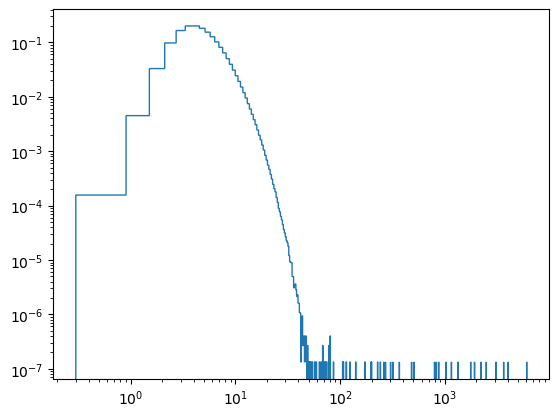

In [58]:
heights, bins, bars = plt.hist(SNRsA0**2, bins=10000, histtype='step', density=True)
#heights2, bins2, bars2 = plt.hist(SNRsA1**2,bin_space, histtype='step', density=True)
plt.yscale('log')
plt.xscale('log')
plt.show()

In [ ]:
from lmfit.models import ExponentialModel

mod = ExponentialModel()



In [158]:
df, nc, loc, scale = ncx2.fit(sampled_peaks, f0=2)

In [1369]:
AI_3std_4 = [event for event in co_events_run4 if event[0][1]['SNR'] > 3 and  event[1][1]['SNR'] > 3]
AI_3std_7 = [event for event in co_events_run7 if event[0][1]['SNR'] > 3 and  event[1][1]['SNR'] > 3]
AI_3std_8 = [event for event in co_events_run8 if event[0][1]['SNR'] > 3 and  event[1][1]['SNR'] > 3]
AI_3std_10 = [event for event in co_events_run10 if event[0][1]['SNR'] > 3 and  event[1][1]['SNR'] > 3]


AI_3std = np.concatenate((AI_3std_4, AI_3std_7, AI_3std_8, AI_3std_10))
SNRsA1_3std = np.array([(AI_3std[event][1][1]['SNR']) for event in range(len(AI_3std))])
SNRsA0_3std = np.array([(AI_3std[event][0][1]['SNR']) for event in range(len(AI_3std))])

In [1374]:
np.max(SNRsA0_3std)

5.059295307957781

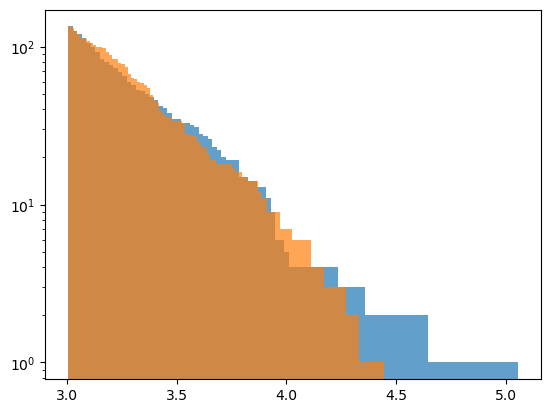

In [1373]:
plt.hist(SNRsA0_3std, bins=100, alpha=0.7, cumulative=-1, density=False)
plt.hist(SNRsA1_3std, bins=100, alpha=0.7, cumulative=-1, density = False)

#plt.xlim(5,1)
plt.yscale('log')
plt.show()

# Catalog of non-thermal Events

## Large energy impulses (single detector)

### code

In [864]:
def large_events_by_SNR(event_catalogue, min_snr, max_snr):
    """
    Selects and saves large events with SNR greater than min_snr and smaller than max_snr,
    along with other event details (time, SNR, input AI, channel, frequency, amplitude, file N, index).
    
    Args:
        event_catalogue (dict): Dictionary containing event data, where each event has keys like 'SNR', 'input AI', 'channel', etc.
        min_snr (float): Minimum SNR value.
        max_snr (float): Maximum SNR value.
        
    Returns:
        dict: Dictionary with event channels and input AI values as keys, containing lists of large event details.
    """
    large_events = {}

    # Loop over all unique values for 'input AI' and 'channel' and find large events based on SNR
    for ai_value in [0, 1]:  # For AI = 0 and AI = 1
        for channel in range(1, 17):  # Assuming channels 1 to 16
            # Get the list of events for a specific channel and input AI
            key = f"AI{ai_value}_ch{channel}_events"
            large_event_details = []  # List to hold all details for large events

            # Loop over the event_catalogue and apply condition based on 'SNR'
            for index, event in enumerate(event_catalogue):
                if (event_catalogue[event]['input AI'] == ai_value and
                    event_catalogue[event]['channel'] == channel):
                    
                    snr_value = event_catalogue[event]['SNR']
                    if min_snr < snr_value < max_snr:  # Check if SNR is within the specified range
                        # Collect all relevant event information
                        event_info = {
                            'time': event_catalogue[event]['time'],
                            'SNR': snr_value,
                            'input AI': event_catalogue[event]['input AI'],
                            'channel': event_catalogue[event]['channel'],
                            'frequency': event_catalogue[event]['frequency'],
                            'amplitude': event_catalogue[event]['amplitude'],
                            'file N': event_catalogue[event]['file N'],
                            'index': event_catalogue[event]['index']
                        }
                        large_event_details.append(event_info)

            # Save the large event details
            large_events[key] = large_event_details

    return large_events

# Example usage
min_snr = thresh
max_snr = 1e99

# Assuming event_catalogue is your data dictionary
large_event_data7 = large_events_by_SNR(event_catalogue_run7, min_snr, max_snr)
large_event_data4 = large_events_by_SNR(event_catalogue_run4, min_snr, max_snr)
large_event_data8 = large_events_by_SNR(event_catalogue_run8, min_snr, max_snr)
large_event_data10 = large_events_by_SNR(event_catalogue_run10, min_snr, max_snr)

In [865]:
ch2_events = np.concatenate((np.array(large_event_data4['AI0_ch2_events']),
                np.array(large_event_data4['AI1_ch2_events']),
                np.array(large_event_data7['AI0_ch2_events']),
                np.array(large_event_data7['AI1_ch2_events']),
                np.array(large_event_data8['AI0_ch2_events']),
                np.array(large_event_data8['AI1_ch2_events']),
                np.array(large_event_data10['AI0_ch2_events']),
                np.array(large_event_data10['AI1_ch2_events']),
                ))
ch3_events = np.concatenate((np.array(large_event_data4['AI0_ch3_events']),
                np.array(large_event_data4['AI1_ch3_events']),
                np.array(large_event_data7['AI0_ch3_events']),
                np.array(large_event_data7['AI1_ch3_events']),
                np.array(large_event_data8['AI0_ch3_events']),
                np.array(large_event_data8['AI1_ch3_events']),
                np.array(large_event_data10['AI0_ch3_events']),
                np.array(large_event_data10['AI1_ch3_events']),
                ))
ch5_events = np.concatenate((np.array(large_event_data4['AI0_ch5_events']),
                np.array(large_event_data4['AI1_ch5_events']),
                np.array(large_event_data7['AI0_ch5_events']),
                np.array(large_event_data7['AI1_ch5_events']),
                np.array(large_event_data8['AI0_ch5_events']),
                np.array(large_event_data8['AI1_ch5_events']),
                np.array(large_event_data10['AI0_ch5_events']),
                np.array(large_event_data10['AI1_ch5_events']),
                ))
ch6_events = np.concatenate((np.array(large_event_data4['AI0_ch6_events']),
                np.array(large_event_data4['AI1_ch6_events']),
                np.array(large_event_data7['AI0_ch6_events']),
                np.array(large_event_data7['AI1_ch6_events']),
                np.array(large_event_data8['AI0_ch6_events']),
                np.array(large_event_data8['AI1_ch6_events']),
                np.array(large_event_data10['AI0_ch6_events']),
                np.array(large_event_data10['AI1_ch6_events']),
                ))

all_events = np.concatenate((ch3_events ,ch2_events, ch5_events, ch6_events))

In [866]:
intervals = [int.seconds for int in np.diff(np.array([event['time'] for event in all_events]))]

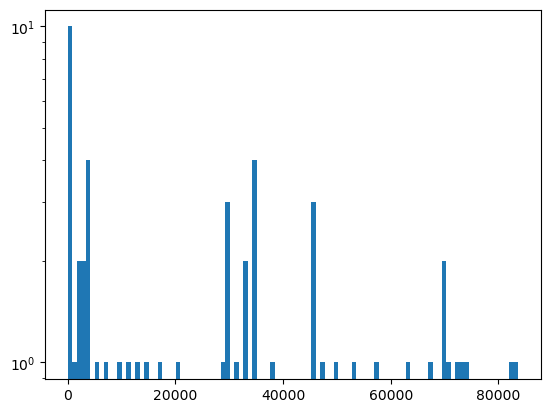

In [867]:
bin_space = np.logspace(0,5, 500)
plt.hist(intervals,bins=100)
#plt.xscale('log')
plt.yscale('log')
plt.show()


In [868]:
def get_energies(event_dict, file_path):
    energies = []
    channel_energy = np.zeros((1,16))
    channel_e_error = np.zeros((1,16))
    inital_file = file_path + str(1) + '.hdf5'
    iq = Analysis_functions.retrieve_IQ_td(inital_file)
    ini_height = np.zeros((2,16))
    for ai in range(2):
        for ch in range(16):
            i_data = iq[ai, ch, 0, :]
            q_data = iq[ai, ch, 1, :]
            r_data = np.sqrt(i_data **2 + q_data**2)
            freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
            junk, junk, junk, junk, junk, junk, junk, ini_height[ai, ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis(
                Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False)
    for channel in event_dict:
        for event in event_dict[channel]:
            index = event['index']
            ch = event['channel'] - 1
            ai = event['input AI']
            file = event['file N']

            file_name = file_path + str(file) + '.hdf5'
            time = dt *  np.linspace(index-offset- span, index-offset + span, 2*span)
            iq = Analysis_functions.retrieve_IQ_td(file_name)
            i_data = iq[ai, ch, 0, :]
            q_data = iq[ai, ch, 1, :]
            r_data = np.sqrt(i_data **2 + q_data**2)
            freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
            fr, sigma, integral, Q, f_res_err, sigma_err, Q_err, height = Analysis_functions.lorentzian_fit_thermalpeak_bis(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False)
            gain_drift_correction = 1 + (ini_height[ai, ch] - height)/ini_height[ai, ch]
            kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Q*Rbaw[ai,ch]))
            strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai]*gain_drift_correction , Min[ai], kappa)
            T = 0.5*(fdemods[ai, ch]*2*np.pi)**2*meff[ch]*strain**2/k
            tau = Q /np.pi / fr
            Nfilter=int(Fs*20*1) # assume 1s tau
            t_sig =1/Fs*np.linspace(0, Nfilter, Nfilter)
            template = np.exp(-t_sig/(2*tau)) # template construction
            SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
            T_filtered = 0.5*(fdemods[ai, ch]*2*np.pi)**2*meff[ch]*np.abs(filtered_strain)**2/k
            Qerr_percentage = Q_err/Q
            df, loc, scale = chi2.fit([t for t in T if t < 20], f0=2)
            T_normed = T_filtered
            df, loc2, scale2 = chi2.fit([t for t in T_normed if t < 2*scale], f0=2)

            #Teff = 3.6/(scale*2)*(2*scale2)
            Teff = (2*scale2)
            Ek = event['SNR']**2*Teff
            energies.append(Ek)
            Ek_ch_array = np.zeros((16))
            Ek_ch_error = np.zeros((16))
            Ek_ch_array[ch] = Ek
            Ek_ch_error[ch] = Qerr_percentage*Teff
            channel_energy = np.append(channel_energy, [Ek_ch_array], axis=0)
            channel_e_error = np.append(channel_e_error, [Ek_ch_error], axis=0)
    return energies, channel_energy, channel_e_error

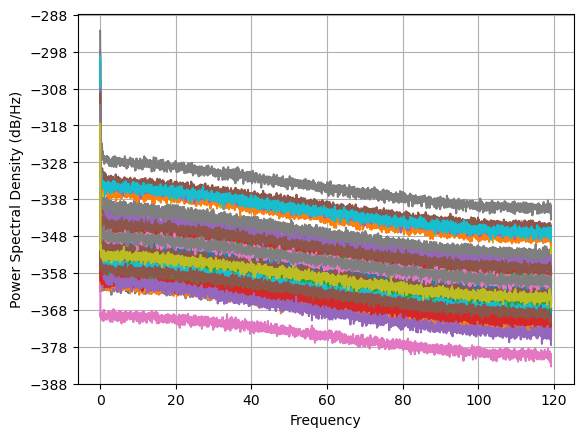

In [ ]:
span = 500
offset = 0
NFFT=2**13
energies4, channel_e4, error_e4  = get_energies(large_event_data4,r'C:\Users\00103619\MAGE\MAGE4\run4\\' + 'run4--')
energies7, channel_e7, error_e7 = get_energies(large_event_data7,r'C:\Users\00103619\MAGE\MAGE4\run7\\' + 'run7-')
energies8, channel_e8, error_e8 = get_energies(large_event_data8,r'C:\Users\00103619\MAGE\MAGE4\run8\\' + 'run8-')
energies10, channel_e10, error_e10 = get_energies(large_event_data10,r'C:\Users\00103619\MAGE\MAGE4\run10\\' + 'run10-')




In [870]:
fdemods

array([[ 4993040.,  5080779.,  5088540., ...,  9247256.,  9527651.,
        15734386.],
       [ 4993066.,  5080868.,  5088278., ...,  9246900.,  9526488.,
        15731972.]])

In [871]:
energy_total = np.concatenate((energies4, energies7, energies8, energies10))
channel_e_total = np.concatenate((channel_e4, channel_e7, channel_e8, channel_e10), axis = 0)
channel_e_error = np.concatenate((error_e4, error_e7, error_e8, error_e10), axis = 0)

In [872]:
cmap = cm.seismic(np.linspace(0, 1, 16))

In [1037]:
sort_by_Q = np.argsort(np.mean([Q0,Q1],axis=0))
sort_by_BW = np.argsort(np.mean([Q0,Q1],axis=0)/fdemods[1][:])
meanQ = np.mean([Q0,Q1],axis=0)
labels = ['C300', 'C302', 'C320', 'B300', 'B302', 'C520', 'B500','B524', 'A300', 'B320', 'C500', 'C502', 'B520', 'B502', 'A320', 'A500']
channel_e_sorted = np.zeros(channel_e_total.shape)
Q_sorted = np.zeros((16))
fres_sorted = np.zeros((16))
labels_sorted = []
for i in range(16):
    Q_sorted[i] = meanQ[sort_by_BW[i]]
    fres_sorted[i] = fdemods[0][sort_by_BW[i]]
    channel_e_sorted[:, i] = channel_e_total[:,sort_by_BW[i]]
    label_string = r'$' + (labels[sort_by_Q[i]])[0] + r'_{' + (labels[sort_by_Q[i]])[1:] + r'},' + r'%1.1f$' %(meanQ[sort_by_Q[i]]/1e7)
    labels_sorted.append(label_string)


In [1038]:
def log_bins(data, num_bins):
    """
    Divide a dataset into logarithmically spaced bins.

    Parameters:
        data (array-like): The input data array.
        num_bins (int): Number of logarithmic bins.

    Returns:
        bins (ndarray): The edges of the logarithmic bins.
        digitized (ndarray): Indices of the bins to which each value in input array belongs.
    """
    data = np.array(data)
    # Ensure data is strictly positive, since log scale can't handle zero or negative values
    data = data[data > 0]

    min_val = data.min()
    max_val = data.max()

    # Create logarithmic bins
    bins = np.logspace(np.log10(min_val), np.log10(max_val), num_bins + 1)

    # Assign each data point to a bin
    digitized = np.digitize(data, bins)

    return bins, digitized
def sum_by_bin(arr, bin_indices):
    num_bins = bin_indices.max() + 1
    summed = np.zeros((num_bins, arr.shape[1]))
    for i in range(arr.shape[1]):
        summed[:, i] = np.bincount(bin_indices, weights=arr[:, i], minlength=num_bins)
    return summed

In [1]:
cmap =  plt.cm.viridis(np.linspace(0, 1, 16))
Nbins = 10
bin_space = np.logspace(-3,4,Nbins+1)
hists = np.zeros((16, Nbins))
hists_error = np.zeros((16, Nbins))
h_edges = np.zeros((16, Nbins+1))

#counts, edges, bars = plt.hist(channel_e_sorted[:,0], bins=bin_space, histtype='step', cumulative=0, linewidth=2.0)
counts, edges, bars = plt.hist(channel_e_total, bins=bin_space, stacked=False, color=cmap, alpha = 1.0, cumulative=0, density=False, label = labels_sorted)
# for i in range(16):
#     energies = [e for e in channel_e_total[:,i] if e != 0]
#     hists[i,:], h_edges[i,:], bars = plt.hist(energies, bins=bin_space, histtype='step', cumulative=0, label = f'Ch {i}', color = next(cmap))
centers = ((edges[:-1]+ edges[1:]) / 2)
plt.errorbar(centers , counts[-1,:], yerr =  np.sqrt(counts[-1,:]), linestyle = ' ', capsize = 3.0, color = 'black', marker = 'o', markersize = 3.0)
plt.xlabel('Energy (K)')
plt.ylabel('N')
plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-2,1e5)
plt.legend(loc = 0, fontsize=9.2, ncol=1)
pp = 'per-channel-absorption-hist.pdf'
plt.savefig(pp, format = 'pdf', dpi=600)

NameError: name 'plt' is not defined

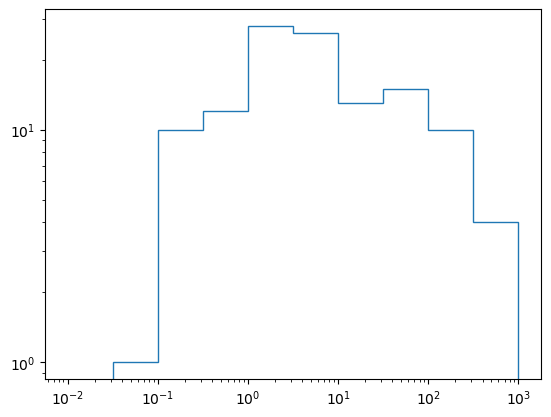

In [1056]:
Nbins=10
bin_space = np.logspace(-2,3,Nbins+1)
plt.hist(energy_total, bins=bin_space, histtype='step', cumulative=0, density=False)
plt.yscale('log')
plt.xscale('log')

In [1057]:
Qbins, indicies  = log_bins(Q_sorted, 10)

In [1058]:
means = np.mean(channel_e_sorted, axis=0)

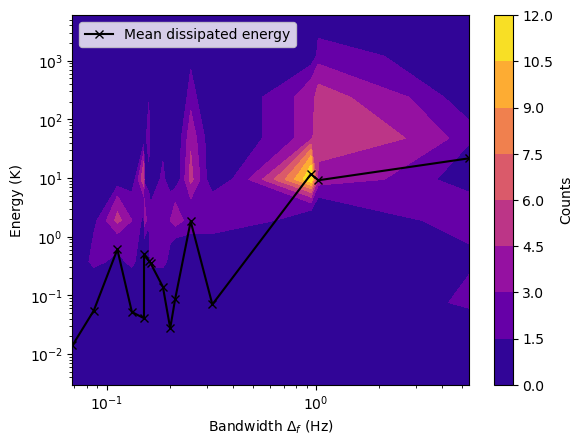

In [1061]:
XX, YY = np.meshgrid((fres_sorted/Q_sorted), centers)


totals = np.sum(channel_e_sorted, axis=0)
plt.yscale('log')
plt.xscale('log')
plt.plot((fres_sorted/Q_sorted), means, '-', color='black', label = 'Mean dissipated energy', marker='x')
plt.contourf(XX, YY, np.transpose(counts), cmap='plasma')
plt.colorbar(label='Counts')
plt.legend(loc=2)
plt.xlabel(r'Bandwidth $\Delta_f$ (Hz)')
plt.ylabel('Energy (K)')
pp = 'per-channel-absorption-hist.pdf'
plt.savefig(pp, format = 'pdf', dpi=600)

In [947]:
Q_sorted

array([9.427335e+05, 4.974284e+06, 5.902717e+06, ..., 8.237134e+07,
       1.064733e+08, 1.390596e+08])

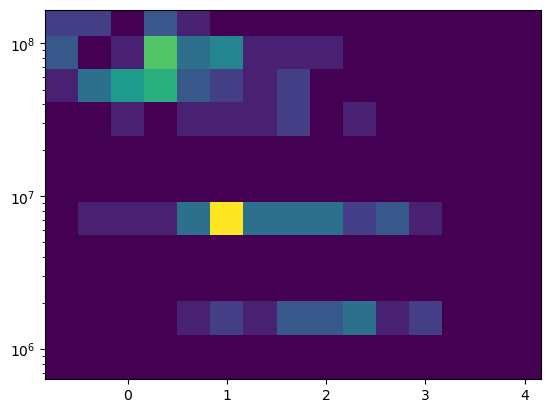

In [880]:
XX, YY = np.meshgrid(np.log10(edges[1:]), Qbins)
ZZ = counts_summed
plt.yscale('log')
plt.pcolormesh(XX,YY,ZZ)

In [948]:
totals = np.sum(channel_e_total, axis=0)
Qs_avg = np.mean([Q0,Q1],axis=0)
slow_shear = [totals[0], totals[1], totals[2], totals[10], totals[5], totals[11]]
slow_Qs = [Qs_avg[0], Qs_avg[1], Qs_avg[2], Qs_avg[10], Qs_avg[5], Qs_avg[11]]
slow_fs = [f_res[0,:][0], f_res[0,:][1], f_res[0,:][2], f_res[0,:][10], f_res[0,:][5], f_res[0,:][11]]
C_resistances = [11.0, 320, 130, 19, 24, 63]

fast_shear = [totals[3], totals[4], totals[9], totals[6], totals[12], totals[13], totals[7]]
fast_Qs = [Qs_avg[3], Qs_avg[4], Qs_avg[9], Qs_avg[6], Qs_avg[12], Qs_avg[13], Qs_avg[7]]
B_resistances = [12, 110.0, 30, 17.0, 22, 23, 86]
fast_fs = [f_res[0,:][3], f_res[0,:][4], f_res[0,:][9], f_res[0,:][6], f_res[0,:][12], f_res[0,:][13], f_res[0,:][7]]

long = [totals[8], totals[14], totals[15]]
long_Qs = [Qs_avg[8], Qs_avg[14], Qs_avg[15]]
A_resistances =[17, 16, 51]
long_fs = [f_res[0,:][8], f_res[0,:][14], f_res[0,:][15]]

In [1003]:
slow_shear_x = ['$C_{300}$', '$C_{302}$', '$C_{320}$', '$C_{500}$', '$C_{502}$', '$C_{520}$']
fast_shear_x = ['$B_{300}$', '$B_{302}$', '$B_{320}$', '$B_{500}$', '$B_{520}$', '$B_{502}$', '$B_{524}$']
long_x = ['$A_{300}$', '$A_{320}$', '$A_{500}$']

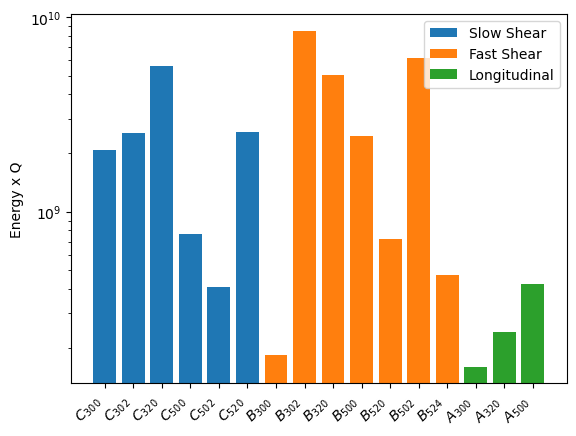

In [1008]:
plt.bar(slow_shear_x, np.array(slow_shear)*np.array(slow_Qs), label = 'Slow Shear')
plt.bar(fast_shear_x, np.array(fast_shear)*np.array(fast_Qs), label = 'Fast Shear')
plt.bar(long_x, np.array(long)*np.array(long_Qs), label = 'Longitudinal')
plt.yscale('log')
plt.ylabel('Energy x Q')
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.show()

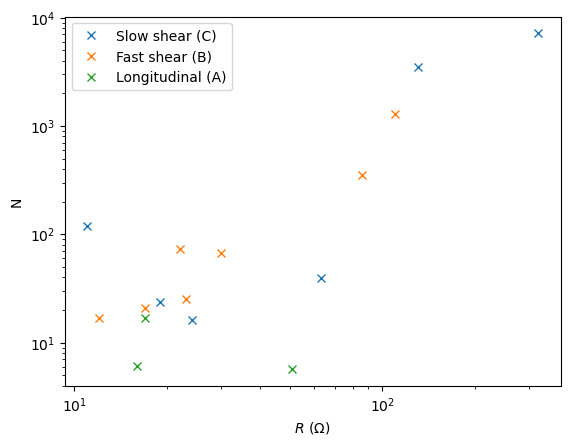

In [128]:
plt.plot(C_resistances, slow_shear ,'x', label = 'Slow shear (C)')
plt.plot(B_resistances, fast_shear, 'x', label = 'Fast shear (B)')
plt.plot(A_resistances, long, 'x', label = 'Longitudinal (A)')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$R~(\Omega)$')
plt.ylabel(r'N')
plt.legend()

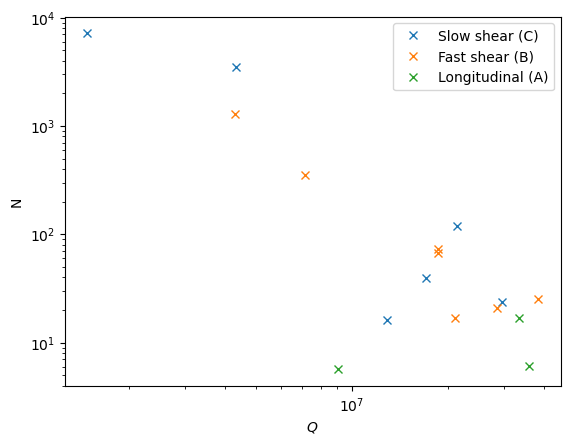

In [177]:
plt.plot(slow_Qs, slow_shear ,'x', label = 'Slow shear (C)')
plt.plot(fast_Qs, fast_shear, 'x', label = 'Fast shear (B)')
plt.plot(long_Qs, long, 'x', label = 'Longitudinal (A)')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$Q$')
plt.ylabel(r'N')
plt.legend()

In [ ]:
Rt = 3.0**2
1/(np.sqrt(2*np.pi*Rt))*np.exp((-R+Rt)/2)np.cosh(np.sqrt(R*Rt))